# Module 3 Lab 3

Import the bridges.csv data set
Address all missing values
Look for outliers and noisy data
Prepare the data set to establish a relation among:
+ Length of bridge and purpose
+ Number of lanes and materials
+ Span of bridge and number of lanes

In [1]:
import pandas as pd
originaldf = pd.read_csv('bridges.csv')
df = originaldf

In [2]:
df.shape

(108, 13)

In [3]:
df.head()

,Id,river,location,erected,purpose,length,lanes,clear-g,t-or-d,material,span,rel-l,type
0,E1,M,3.0,1818,HIGHWAY,NaN,2.0,N,THROUGH,WOOD,SHORT,S,WOOD
1,E2,A,25.0,1819,HIGHWAY,1037.0,2.0,N,THROUGH,WOOD,SHORT,S,WOOD
2,E3,A,39.0,1829,AQUEDUCT,NaN,1.0,N,THROUGH,WOOD,NaN,S,WOOD
3,E5,A,29.0,1837,HIGHWAY,1000.0,2.0,N,THROUGH,WOOD,SHORT,S,WOOD
4,E6,M,23.0,1838,HIGHWAY,NaN,2.0,N,THROUGH,WOOD,NaN,S,WOOD


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Id        108 non-null    str    
 1   river     108 non-null    str    
 2   location  107 non-null    float64
 3   erected   108 non-null    int64  
 4   purpose   108 non-null    str    
 5   length    81 non-null     float64
 6   lanes     92 non-null     float64
 7   clear-g   106 non-null    str    
 8   t-or-d    102 non-null    str    
 9   material  106 non-null    str    
 10  span      92 non-null     str    
 11  rel-l     103 non-null    str    
 12  type      106 non-null    str    
dtypes: float64(3), int64(1), str(9)
memory usage: 14.7 KB


In [5]:
df.describe()

,location,erected,length,lanes
count,107.000000,108.000000,81.000000,92.000000
mean,25.978505,1905.314815,1567.469136,2.630435
std,13.665871,37.173664,747.491523,1.164657
min,1.000000,1818.000000,804.000000,1.000000
25%,15.500000,1884.000000,1000.000000,2.000000
50%,27.000000,1903.000000,1300.000000,2.000000
75%,37.500000,1928.000000,2000.000000,4.000000
max,52.000000,1986.000000,4558.000000,6.000000


In [6]:
df.isnull().sum()

Id           0
river        0
location     1
erected      0
purpose      0
length      27
lanes       16
clear-g      2
t-or-d       6
material     2
span        16
rel-l        5
type         2
dtype: int64

In [7]:
print(df.duplicated().sum())

0


<Axes: >

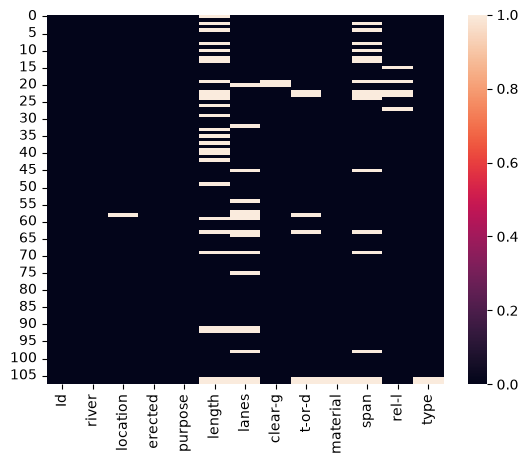

In [8]:
import seaborn as sns
sns.heatmap(df.isnull())

In [9]:
df[df["length"]>2000]

,Id,river,location,erected,purpose,length,lanes,clear-g,t-or-d,material,span,rel-l,type
31,E34,O,41.0,1888,RR,4558.0,2.0,G,THROUGH,STEEL,LONG,F,SIMPLE-T
41,E42,M,9.0,1895,HIGHWAY,2367.0,2.0,G,THROUGH,STEEL,LONG,F,SIMPLE-T
44,E46,A,37.0,1897,RR,4000.0,2.0,G,DECK,STEEL,LONG,F,SIMPLE-T
45,E45,M,14.0,1897,RR,2264.0,NaN,G,THROUGH,STEEL,NaN,F,SIMPLE-T
52,E87,A,35.0,1903,RR,3000.0,2.0,G,THROUGH,STEEL,MEDIUM,S,SIMPLE-T
64,E92,M,10.0,1914,RR,2210.0,NaN,G,THROUGH,STEEL,MEDIUM,F,SIMPLE-T
65,E61,O,41.0,1915,RR,2822.0,2.0,G,THROUGH,STEEL,LONG,F,SIMPLE-T
67,E62,A,37.0,1918,RR,2300.0,2.0,N,DECK,STEEL,LONG,F,CONT-T
68,E63,A,31.0,1920,RR,2122.0,2.0,G,THROUGH,STEEL,MEDIUM,F,SIMPLE-T
71,E66,A,32.0,1924,HIGHWAY,2365.0,4.0,G,THROUGH,STEEL,MEDIUM,S,ARCH


In [10]:
df[df["length"]>3000]

,Id,river,location,erected,purpose,length,lanes,clear-g,t-or-d,material,span,rel-l,type
31,E34,O,41.0,1888,RR,4558.0,2.0,G,THROUGH,STEEL,LONG,F,SIMPLE-T
44,E46,A,37.0,1897,RR,4000.0,2.0,G,DECK,STEEL,LONG,F,SIMPLE-T
104,E91,O,44.0,1975,HIGHWAY,3756.0,6.0,G,THROUGH,STEEL,LONG,F,ARCH


# Initial Data Summary

Imported a (108, 13) dataframe
There are many more columns than we need for this project.
+ We need five: Length, Purpose, Number of Lanes, Materials, Span

We are missing quite a few lengths (27), lanes (16), span (16), and missing material (2). 

Some trends:
+ When sorted by date, material trend is wood and iron before 1874, then all steel beginning in 1895.
+ There are 4 aqueducts, two with missing lengths.
+ There are 71 highway bridges, 14 NA for length. Min 804, Max is 3756, median 1240.
+ There are 32 RR bridges, 10 NA for length. Min is 840, Max is 4558, median 1460.
+ There is one walking bridge with no length, lane or span data.
+ There are 2 missing materials. Those can be deduced to be steel, based on there construction dates (1982, 1986). However all length, lane, and span data are missing so these rows will be dropped.


Possible outliers - length of bridges. The longest wood/iron bridge has a value of 1500. The 75% quartile of the bridge lengths have a maximum of 2000 and the max is 4558, this is a large jump. However, there are numerous lengths in the 2000s. Three values are far above...all of these are steel, two are RR and one HWY, two are built in 1888 and 1897 and 1975. I Googled longest bridges built in the US before 1910 and it is feasible that these values are valid. Therefore, I am claiming no outliers in bridge length values.


In [11]:
df.shape

(108, 13)

# Drop 2 missing materials series (index 2, 8)
There are 2 series with missing materials. Those can be deduced to be steel, based on there construction dates (1982, 1986). However all length, lane, and span data are missing so these series will be dropped.


In [12]:
miss_material = df[df["material"].isna()]
print(miss_material)

       Id river  location  erected  purpose  length  lanes clear-g t-or-d  \
106  E100     O      43.0     1982  HIGHWAY     NaN    NaN       G    NaN   
107  E109     A      28.0     1986  HIGHWAY     NaN    NaN       G    NaN   

    material span rel-l type  
106      NaN  NaN     F  NaN  
107      NaN  NaN     F  NaN  


In [13]:
df = df.dropna(subset = ["material"])

In [14]:
df.shape

(106, 13)

In [15]:
aqueducts = df[df["purpose"] == "AQUEDUCT"]
print (aqueducts)

     Id river  location  erected   purpose  length  lanes clear-g   t-or-d  \
2    E3     A      39.0     1829  AQUEDUCT     NaN    1.0       N  THROUGH   
6    E8     A      28.0     1844  AQUEDUCT  1000.0    1.0       N  THROUGH   
8   E10     A      39.0     1848  AQUEDUCT     NaN    1.0       N     DECK   
38   E4     A      27.0     1892  AQUEDUCT  1092.0    1.0       N  THROUGH   

   material   span rel-l    type  
2      WOOD    NaN     S    WOOD  
6      IRON  SHORT     S  SUSPEN  
8      WOOD    NaN     S    WOOD  
38     WOOD  SHORT     S    WOOD  


# Drop aqueducts with missing lengths
Insufficient data to impute the two missing lengths from the two existing lengths. We have all the data for an iron suspension aqueduct and a wooden short span aqueduct. This does not provide enough data to impute the span and length of two missing wooden aqueducts. REMOVE THESE series from df.

In [16]:
df.shape

(106, 13)

In [17]:
df.head(10)

,Id,river,location,erected,purpose,length,lanes,clear-g,t-or-d,material,span,rel-l,type
0,E1,M,3.0,1818,HIGHWAY,NaN,2.0,N,THROUGH,WOOD,SHORT,S,WOOD
1,E2,A,25.0,1819,HIGHWAY,1037.0,2.0,N,THROUGH,WOOD,SHORT,S,WOOD
2,E3,A,39.0,1829,AQUEDUCT,NaN,1.0,N,THROUGH,WOOD,NaN,S,WOOD
3,E5,A,29.0,1837,HIGHWAY,1000.0,2.0,N,THROUGH,WOOD,SHORT,S,WOOD
4,E6,M,23.0,1838,HIGHWAY,NaN,2.0,N,THROUGH,WOOD,NaN,S,WOOD
5,E7,A,27.0,1840,HIGHWAY,990.0,2.0,N,THROUGH,WOOD,MEDIUM,S,WOOD
6,E8,A,28.0,1844,AQUEDUCT,1000.0,1.0,N,THROUGH,IRON,SHORT,S,SUSPEN
7,E9,M,3.0,1846,HIGHWAY,1500.0,2.0,N,THROUGH,IRON,SHORT,S,SUSPEN
8,E10,A,39.0,1848,AQUEDUCT,NaN,1.0,N,DECK,WOOD,NaN,S,WOOD
9,E11,A,29.0,1851,HIGHWAY,1000.0,2.0,N,THROUGH,WOOD,MEDIUM,S,WOOD


In [18]:
df = df.drop(8)
df = df.drop(2)

In [19]:
df.shape

(104, 13)

In [20]:
df.head(10)

,Id,river,location,erected,purpose,length,lanes,clear-g,t-or-d,material,span,rel-l,type
0,E1,M,3.0,1818,HIGHWAY,NaN,2.0,N,THROUGH,WOOD,SHORT,S,WOOD
1,E2,A,25.0,1819,HIGHWAY,1037.0,2.0,N,THROUGH,WOOD,SHORT,S,WOOD
3,E5,A,29.0,1837,HIGHWAY,1000.0,2.0,N,THROUGH,WOOD,SHORT,S,WOOD
4,E6,M,23.0,1838,HIGHWAY,NaN,2.0,N,THROUGH,WOOD,NaN,S,WOOD
5,E7,A,27.0,1840,HIGHWAY,990.0,2.0,N,THROUGH,WOOD,MEDIUM,S,WOOD
6,E8,A,28.0,1844,AQUEDUCT,1000.0,1.0,N,THROUGH,IRON,SHORT,S,SUSPEN
7,E9,M,3.0,1846,HIGHWAY,1500.0,2.0,N,THROUGH,IRON,SHORT,S,SUSPEN
9,E11,A,29.0,1851,HIGHWAY,1000.0,2.0,N,THROUGH,WOOD,MEDIUM,S,WOOD
10,E12,A,39.0,1853,RR,NaN,2.0,N,DECK,WOOD,NaN,S,WOOD
11,E14,M,6.0,1856,HIGHWAY,1200.0,2.0,N,THROUGH,WOOD,MEDIUM,S,WOOD


In [21]:
df.groupby("purpose")["length"].mean()

purpose
AQUEDUCT    1046.000000
HIGHWAY     1469.052632
RR          1869.863636
WALK                NaN
Name: length, dtype: float64

In [22]:
df.groupby("purpose")["length"].min()

purpose
AQUEDUCT    1000.0
HIGHWAY      804.0
RR           840.0
WALK           NaN
Name: length, dtype: float64

In [23]:
df.groupby("purpose")["length"].max()

purpose
AQUEDUCT    1092.0
HIGHWAY     3756.0
RR          4558.0
WALK           NaN
Name: length, dtype: float64

In [24]:
df.groupby("purpose")["length"].count()

purpose
AQUEDUCT     2
HIGHWAY     57
RR          22
WALK         0
Name: length, dtype: int64

In [25]:
df.groupby("span")["lanes"].median()

span
LONG      2.0
MEDIUM    2.0
SHORT     2.0
Name: lanes, dtype: float64

In [26]:
df.groupby("span")["lanes"].mean()

span
LONG      3.185185
MEDIUM    2.608696
SHORT     2.000000
Name: lanes, dtype: float64

In [27]:
df.groupby("material")["lanes"].mean()

material
IRON     1.900000
STEEL    2.909091
WOOD     2.071429
Name: lanes, dtype: float64

# Dropping or Imputing
Dropping or imputing the remaining lengths, lanes, and spans - I do not see any obvious trends in the data with the exception that steel came later than wood and iron. There does not seem to be a trend with length based on materials, dates of construction, or purpose.

These data will be used to establish relationships between length and lanes, lanes and materials, and span and lanes. Since no obvious trends can be found that would justify imputing mean or median values, the missing values will be dropped to make a clean data set.

In [28]:
df = df.dropna(subset = ["lanes"])

In [29]:
df.shape

(90, 13)

If we drop series with missing lanes, we go from 104 to 90 series.

In [30]:
df = df.dropna(subset = ["length"])

In [31]:
df.shape

(72, 13)

If we drop series with missing lengths, we go from 90 to 72 series. Now we have half the data we started with but it is clean.

In [32]:
df.isnull().sum()

Id          0
river       0
location    0
erected     0
purpose     0
length      0
lanes       0
clear-g     0
t-or-d      0
material    0
span        0
rel-l       2
type        0
dtype: int64

In [33]:
df.describe()

,location,erected,length,lanes
count,72.000000,72.000000,72.000000,72.000000
mean,25.148611,1910.486111,1582.166667,2.833333
std,13.278703,36.096503,774.715523,1.233340
min,1.000000,1819.000000,840.000000,1.000000
25%,14.750000,1889.500000,1000.000000,2.000000
50%,27.000000,1913.000000,1310.000000,2.000000
75%,35.250000,1932.500000,2000.000000,4.000000
max,49.000000,1978.000000,4558.000000,6.000000


# Data cleaning summary

Main Task:
Prepare the data set to establish a relation among:
+ Length of bridge and purpose
+ Number of lanes and materials
+ Span of bridge and number of lanes

The orginal data set was a (108, 13) dataframe. 

Five of the 13 columns: Length, Purpose, Number of Lanes, Materials, Span are of utmost importance.

Missing data in the five columns: lengths (27), lanes (16), span (16), and material (2).

Cleaning steps taken:
+ No outliers defined - length of bridges was examined for outliers. The longest wood/iron bridge has a value of 1500. The 75% quartile of the bridge lengths have a maximum of 2000 and the max is 4558, this is a large jump. However, there are numerous lengths in the 2000s. Three values are above 3500...all of these are steel, two are RR and one HWY, two are built in 1888 and 1897 and 1975. I Googled longest bridges built in the US before 1910 and it is feasible that these values are valid. Therefore, I am claiming no outliers in bridge length values.
+ Imputing - I do not see any obvious trends in the data with the exception that steel came later than wood and iron. There does not seem to be a trend with length based on materials, dates of construction, river, or purpose. The cleaned data will be used to establish relationships between length and lanes, lanes and materials, and span and lanes. Since no obvious trends can be found that would justify imputing mean or median values, the missing values will be dropped to make a clean data set.
+ Dropping -
+ Drop the 2 missing materials series (index 2, 8) since values were missing for all of our parameters of interest.
+ Drop the 2 aqueduct bridges due to lack of comparable data (see notes in code)
+ Drop all series with missing lane values
+ Drop all series with missing length values.

Final data set (72,13) compared to the original (108, 13).

In [34]:
df.to_csv("bridges_clean.csv", index=False)

https://github.com/acamend/cs82a-portfolio